# Moller scattering of Lorentz-covariant vortex packets

Numerical evaluation of the packet normalization, S-matrix, differential probability, and mean total momentum. Natural units $\hbar=c=1$ are used; energies and momenta are in MeV and impact parameters are in MeV$^{-1}$.

## Import

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

import moller_vortex as mv

MEV_TO_EV = 1.0e6
SHOW_PROGRESS = True

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 11.0,
    "axes.titlesize": 15.0,
    "axes.labelsize": 13.0,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 10.0,
    "axes.linewidth": 0.9,
    "lines.linewidth": 1.8,
})

FIGURE_DIRECTORY = Path("figures")
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)


def make_packet(
    *, ell, sigma_perp, sigma_parallel, sigma_energy, k0_z,
    normalization_nodes=97, normalization_widths=12.0,
):
    central_energy = np.sqrt(mv.ELECTRON_MASS**2 + k0_z**2)
    velocity = k0_z / central_energy
    k_perp_scale = sigma_perp / np.sqrt(2.0)
    k_z_scale = (
        2.0 * velocity**2 / sigma_energy**2
        + 2.0 / sigma_parallel**2
    ) ** (-0.5)
    normalization_grid = mv.NormalizationGrid(
        k_perp=mv.Axis(
            0.0, normalization_widths * k_perp_scale, normalization_nodes, "gauss"
        ),
        k_z=mv.Axis(
            k0_z - normalization_widths * k_z_scale,
            k0_z + normalization_widths * k_z_scale,
            normalization_nodes,
            "gauss",
        ),
    )
    return mv.VortexPacket(
        ell=ell,
        sigma_perp=sigma_perp,
        sigma_parallel=sigma_parallel,
        sigma_energy=sigma_energy,
        k0_z=k0_z,
        normalization_grid=normalization_grid,
    )


def rebuild_packet(packet, **changes):
    if all(getattr(packet, name) == value for name, value in changes.items()):
        return packet
    parameters = {
        name: getattr(packet, name)
        for name in ("ell", "sigma_perp", "sigma_parallel", "sigma_energy", "k0_z")
    }
    parameters.update(changes)
    return make_packet(**parameters)


def print_packet(name, packet):
    print(
        f"{name}:\n"
        f"  ell            = {packet.ell:+d}\n"
        f"  sigma_perp     = {mv.HBARC_MEV_NM / packet.sigma_perp:.8g} nm\n"
        f"  sigma_parallel = {mv.HBARC_MEV_NM / packet.sigma_parallel:.8g} nm\n"
        f"  sigma_energy   = {packet.sigma_energy:.8e} MeV\n"
        f"  k0_z           = {packet.k0_z:+.8e} MeV\n"
        f"  N              = {packet.norm:.12e} MeV^-1"
    )


def save_figure(fig, filename, *, tight_layout=True):
    if tight_layout:
        fig.tight_layout()
    path = FIGURE_DIRECTORY / filename
    fig.savefig(path, dpi=300, bbox_inches="tight", pad_inches=0.08, facecolor="white")
    print(f"Saved figure: {path}")
    plt.show()


def set_probability_scale(ax, values):
    positive = values[np.isfinite(values) & (values > 0.0)]
    if positive.max() / positive.min() > 30.0:
        ax.set_yscale("log")
        return
    center = values[len(values) // 2]
    half_range = max(0.02 * abs(center), 1.1 * np.max(np.abs(values - center)))
    ax.set_ylim(center - half_range, center + half_range)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useMathText=True)
    if np.ptp(values) / abs(center) < 1.0e-3:
        ax.text(0.04, 0.08, "constant at the plotted scale", transform=ax.transAxes, fontsize=7)


c:\Users\User\Documents\moller_vortex\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Wave packet definition and normalization integral

In [2]:
ell_1, ell_2 = 5, 0
k0_z = 10.0  # MeV

sigma_perp1 = mv.spatial_width_nm_to_momentum_mev(10.0)
sigma_perp2 = mv.spatial_width_nm_to_momentum_mev(2.0)
sigma_parallel1 = mv.spatial_width_nm_to_momentum_mev(5.0)
sigma_parallel2 = mv.spatial_width_nm_to_momentum_mev(1.0)
sigma_energy1 = 3.94653961e-5  # MeV
sigma_energy2 = 1.97326980e-4  # MeV
impact_nm = np.array((5.0, 0.0))

ell_pairs = (
    (5, -3), (5, -4), (5, -5), (5, 0),
    (5, 3), (5, 4), (5, 5), (5, 6),
)

In [3]:
packet1 = make_packet(
    ell=ell_1,
    sigma_perp=sigma_perp1,
    sigma_parallel=sigma_parallel1,
    sigma_energy=sigma_energy1,
    k0_z=+k0_z,
)
packet2 = make_packet(
    ell=ell_2,
    sigma_perp=sigma_perp2,
    sigma_parallel=sigma_parallel2,
    sigma_energy=sigma_energy2,
    k0_z=-k0_z,
)

sigma_total_perp = np.hypot(packet1.sigma_perp, packet2.sigma_perp)

In [4]:
impact = impact_nm / mv.HBARC_MEV_NM

print_packet("Packet 1", packet1)
print()
print_packet("Packet 2", packet2)
print(f"\nImpact parameter = ({impact_nm[0]:.8g}, {impact_nm[1]:.8g}) nm")

Packet 1:
  ell            = +5
  sigma_perp     = 10 nm
  sigma_parallel = 5 nm
  sigma_energy   = 3.94653961e-05 MeV
  k0_z           = +1.00000000e+01 MeV
  N              = 2.864355070567e+08 MeV^-1

Packet 2:
  ell            = +0
  sigma_perp     = 2 nm
  sigma_parallel = 1 nm
  sigma_energy   = 1.97326980e-04 MeV
  k0_z           = -1.00000000e+01 MeV
  N              = 2.561957061314e+07 MeV^-1

Impact parameter = (5, 0) nm


## S-matrix at one point

In [ ]:
k3_perp_point = np.array((0.020, 0.004))  # MeV
total_k_perp_point = sigma_total_perp * np.array((0.50, -0.25))

k4_perp_point = total_k_perp_point - k3_perp_point
k3_z_point = np.sqrt(packet1.k0_z**2 - np.sum(k3_perp_point**2))
k4_z_point = -np.sqrt(packet2.k0_z**2 - np.sum(k4_perp_point**2))
momentum_3 = np.array((*k3_perp_point, k3_z_point))
momentum_4 = np.array((*k4_perp_point, k4_z_point))

In [ ]:
S = mv.s_matrix(
    momentum_3,
    momentum_4,
    packet1,
    packet2,
    impact=impact,
)

print(
    f"S = {S.real:+.12e} {S.imag:+.12e}j\n"
    f"|S|^2 = {np.abs(S)**2:.12e}"
)

## Differential-probability grid

In [5]:
# Integration domain
k3_perp_range = (0.010, 0.050)

# Total probability integration
N_total_k_widths = 12.0
total_k_perp_max = N_total_k_widths * sigma_total_perp

In [6]:
# Quadrature
PROBABILITY_RULE = "gauss"
PERIODIC_RULE = "periodic"
N_k3_perp = 32
N_k3_phi = 12
N_total_k_perp = 64
N_total_k_phi = 12

probability_grid = mv.ProbabilityGrid(
    k3_perp=mv.Axis(*k3_perp_range, N_k3_perp, PROBABILITY_RULE),
    k3_phi=mv.Axis(0.0, 2.0 * np.pi, N_k3_phi, PERIODIC_RULE),
    total_k_perp=mv.Axis(
        0.0,
        total_k_perp_max,
        N_total_k_perp,
        PROBABILITY_RULE,
    ),
    total_k_phi=mv.Axis(
        0.0, 2.0 * np.pi, N_total_k_phi, PERIODIC_RULE
    ),
)

Differential probability: 100%|██████████| 1600/1600 [00:00<00:00, 23374.33point/s]


Saved figure: figures\differential_probability_map.png


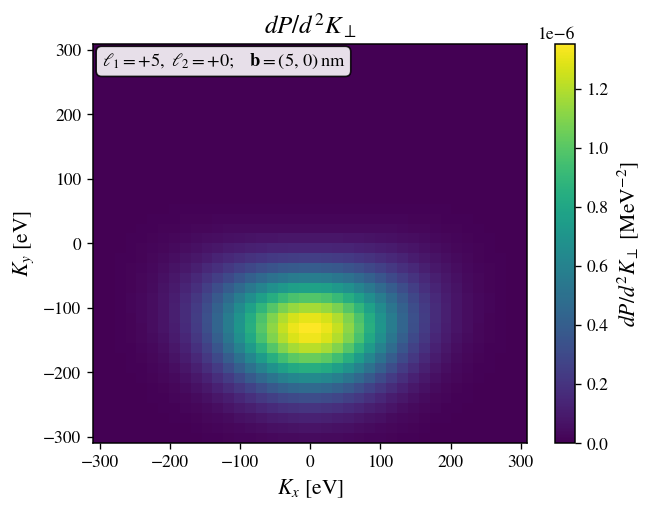

In [7]:
# Cartesian sampling for visualization only
N_map = 40
N_map_half_widths = 3.0

total_k_limit = N_map_half_widths * sigma_total_perp
total_k_x = np.linspace(-total_k_limit, total_k_limit, N_map)
total_k_y = np.linspace(-total_k_limit, total_k_limit, N_map)
probability_map = mv.differential_probability_grid(
    total_k_x,
    total_k_y,
    packet1,
    packet2,
    probability_grid,
    impact=impact,
    progress=SHOW_PROGRESS,
)

fig, ax = plt.subplots(figsize=(5.6, 4.4))
mesh = ax.pcolormesh(
    total_k_x * MEV_TO_EV,
    total_k_y * MEV_TO_EV,
    probability_map,
    shading="auto",
)
ax.set(
    xlabel=r"$K_x$ [eV]",
    ylabel=r"$K_y$ [eV]",
    title=r"$dP/d^2K_\perp$",
)
ax.text(
    0.02, 0.98,
    rf"$\ell_1={packet1.ell:+d},\ \ell_2={packet2.ell:+d};\quad "
    rf"\mathbf{{b}}=({impact_nm[0]:g},\,{impact_nm[1]:g})\,\mathrm{{nm}}$",
    transform=ax.transAxes, ha="left", va="top",
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.88},
)
colorbar = fig.colorbar(mesh, ax=ax)
colorbar.set_label(r"$dP/d^2K_\perp$ [MeV$^{-2}$]")
save_figure(fig, "differential_probability_map.png")

## Differential-probability panel for several angular momenta

The eight panels use the same packet widths, impact parameter, momentum domain, and quadrature. Each panel has its own color scale so that both strong and weak configurations remain visible.


Differential-probability panel: 100%|██████████| 8/8 [00:00<00:00, 12.21panel/s]


Saved figure: figures\differential_probability_oam_panel.png


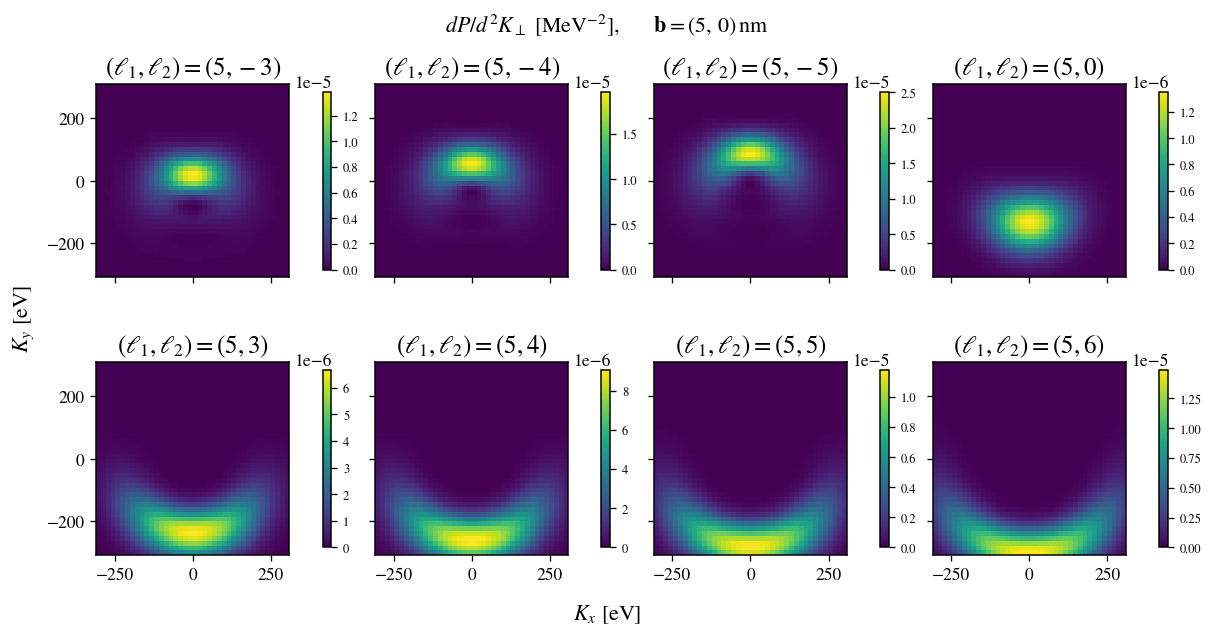

In [8]:
oam_probability_maps = []
for panel_ell1, panel_ell2 in tqdm(
    ell_pairs, desc="Differential-probability panel", unit="panel",
    disable=not SHOW_PROGRESS,
):
    panel_packet1 = rebuild_packet(packet1, ell=panel_ell1)
    panel_packet2 = rebuild_packet(packet2, ell=panel_ell2)
    oam_probability_maps.append(
        mv.differential_probability_grid(
            total_k_x,
            total_k_y,
            panel_packet1,
            panel_packet2,
            probability_grid,
            impact=impact,
        )
    )

oam_probability_maps = np.asarray(oam_probability_maps)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(10.0, 5.2),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
visible_axes = axes.ravel()[:len(ell_pairs)]

for ax, (panel_ell1, panel_ell2), density in zip(
    visible_axes, ell_pairs, oam_probability_maps
):
    mesh = ax.pcolormesh(
        total_k_x * MEV_TO_EV,
        total_k_y * MEV_TO_EV,
        density,
        shading="auto",
        vmin=0.0,
        vmax=np.max(density),
    )
    ax.set_title(rf"$(\ell_1,\ell_2)=({panel_ell1:d},{panel_ell2:d})$")
    ax.set_aspect("equal")
    panel_colorbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.025)
    panel_colorbar.ax.tick_params(labelsize=7.5)

for unused_ax in axes.ravel()[len(ell_pairs):]:
    unused_ax.set_visible(False)

fig.supxlabel(r"$K_x$ [eV]")
fig.supylabel(r"$K_y$ [eV]")
fig.suptitle(
    rf"$dP/d^2K_\perp\ [\mathrm{{MeV}}^{{-2}}],\qquad "
    rf"\mathbf{{b}}=({impact_nm[0]:.4g},\,{impact_nm[1]:.4g})\,\mathrm{{nm}}$"
)
save_figure(fig, "differential_probability_oam_panel.png", tight_layout=False)


## Differential probability at the maximum versus packet widths

The reference point $\mathbf K_\perp^\star$ is the approximate maximum of the already calculated Cartesian probability map; no separate optimization is performed. It remains fixed throughout this section. Each of the six packet widths is varied separately from $10^{-2}$ to $10^2$ of its baseline value, while all other physical parameters remain unchanged. Every varied packet is renormalized on a grid adapted to its new widths.


Reference point near the map maximum:
  K_perp* = (-7.73980095e+00, -1.31576616e+02) eV
  dP/d^2K_perp = 1.351751012971e-06 MeV^-2


Packet-width scans: 100%|██████████| 294/294 [00:00<00:00, 395.12point/s]


Saved figure: figures\differential_probability_width_scans.png


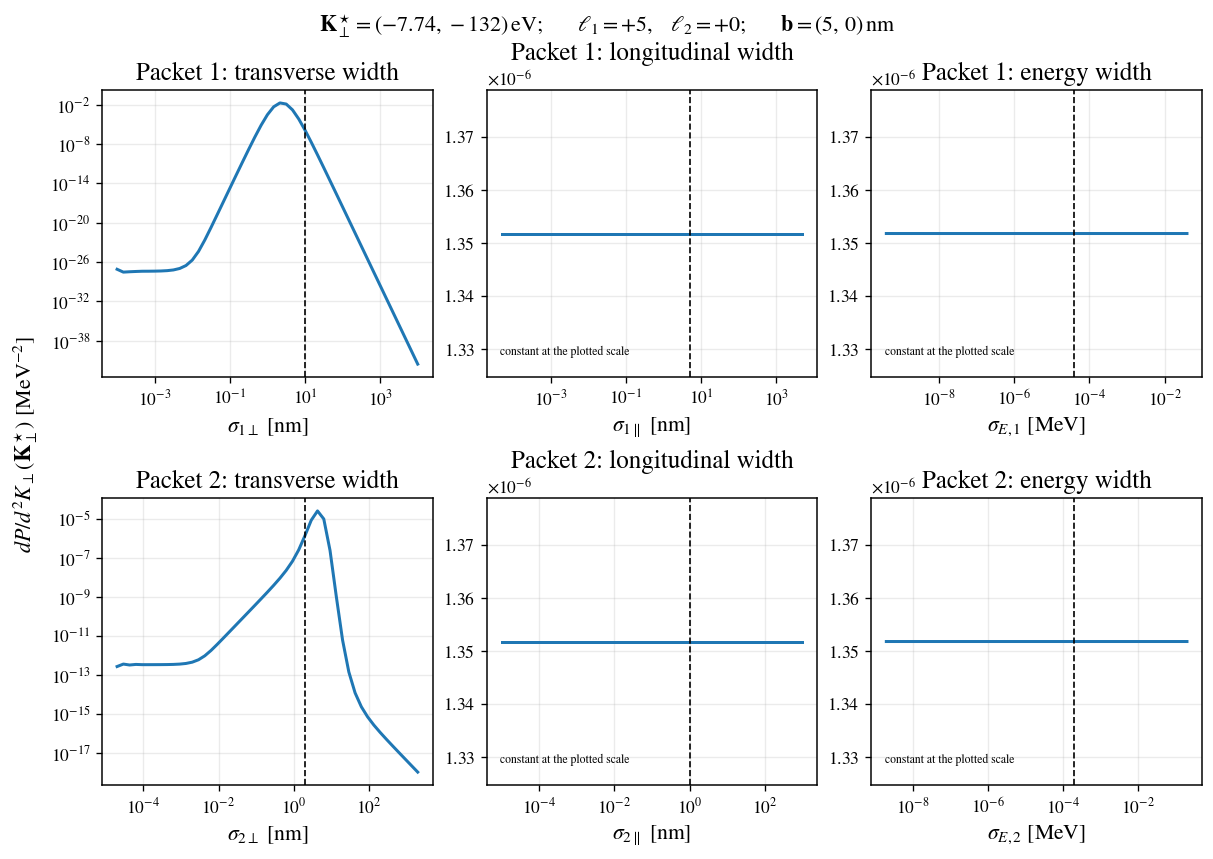

In [19]:
maximum_y_index, maximum_x_index = np.unravel_index(
    np.argmax(probability_map), probability_map.shape
)
maximum_density_point = np.array(
    (total_k_x[maximum_x_index], total_k_y[maximum_y_index])
)
print(
    "Reference point near the map maximum:\n"
    f"  K_perp* = ({maximum_density_point[0] * MEV_TO_EV:+.8e}, "
    f"{maximum_density_point[1] * MEV_TO_EV:+.8e}) eV\n"
    f"  dP/d^2K_perp = {probability_map[maximum_y_index, maximum_x_index]:.12e} MeV^-2"
)


width_scale_factors = np.logspace(-5.0, 3.0, 49)
width_scan_specifications = (
    {
        "packet_index": 0,
        "width_name": "sigma_perp",
        "baseline": mv.HBARC_MEV_NM / packet1.sigma_perp,
        "unit": "nm",
        "xlabel": r"$\sigma_{1\perp}$ [nm]",
        "title": "Packet 1: transverse width",
    },
    {
        "packet_index": 0,
        "width_name": "sigma_parallel",
        "baseline": mv.HBARC_MEV_NM / packet1.sigma_parallel,
        "unit": "nm",
        "xlabel": r"$\sigma_{1\parallel}$ [nm]",
        "title": "Packet 1: longitudinal width",
    },
    {
        "packet_index": 0,
        "width_name": "sigma_energy",
        "baseline": packet1.sigma_energy,
        "unit": "MeV",
        "xlabel": r"$\sigma_{E,1}$ [MeV]",
        "title": "Packet 1: energy width",
    },
    {
        "packet_index": 1,
        "width_name": "sigma_perp",
        "baseline": mv.HBARC_MEV_NM / packet2.sigma_perp,
        "unit": "nm",
        "xlabel": r"$\sigma_{2\perp}$ [nm]",
        "title": "Packet 2: transverse width",
    },
    {
        "packet_index": 1,
        "width_name": "sigma_parallel",
        "baseline": mv.HBARC_MEV_NM / packet2.sigma_parallel,
        "unit": "nm",
        "xlabel": r"$\sigma_{2\parallel}$ [nm]",
        "title": "Packet 2: longitudinal width",
    },
    {
        "packet_index": 1,
        "width_name": "sigma_energy",
        "baseline": packet2.sigma_energy,
        "unit": "MeV",
        "xlabel": r"$\sigma_{E,2}$ [MeV]",
        "title": "Packet 2: energy width",
    },
)

width_scan_results = []
width_progress = tqdm(
    total=len(width_scan_specifications) * len(width_scale_factors),
    desc="Packet-width scans",
    unit="point",
    disable=not SHOW_PROGRESS,
)

for specification in width_scan_specifications:
    displayed_widths = specification["baseline"] * width_scale_factors
    probability_values = np.empty_like(displayed_widths)

    for index, displayed_width in enumerate(displayed_widths):
        native_width = (
            mv.HBARC_MEV_NM / displayed_width
            if specification["unit"] == "nm"
            else displayed_width
        )
        base_packet = packet1 if specification["packet_index"] == 0 else packet2
        varied_packet = rebuild_packet(
            base_packet, **{specification["width_name"]: native_width}
        )
        scan_packet1 = varied_packet if specification["packet_index"] == 0 else packet1
        scan_packet2 = varied_packet if specification["packet_index"] == 1 else packet2
        probability_values[index] = mv.differential_probability(
            maximum_density_point,
            scan_packet1,
            scan_packet2,
            probability_grid,
            impact=impact,
        )
        width_progress.update()

    width_scan_results.append((displayed_widths, probability_values))

width_progress.close()

fig, axes = plt.subplots(
    2, 3, figsize=(10.0, 6.8), constrained_layout=True
)
for scan_index, (ax, specification, scan_result) in enumerate(
    zip(axes.ravel(), width_scan_specifications, width_scan_results)
):
    displayed_widths, probability_values = scan_result
    ax.plot(displayed_widths, probability_values)
    ax.axvline(
        specification["baseline"], color="black", linestyle="--", linewidth=1.0
    )
    ax.set(xlabel=specification["xlabel"], title=specification["title"])
    ax.set_xscale("log")

    set_probability_scale(ax, probability_values)
    ax.grid(which="both", alpha=0.25)

fig.supylabel(r"$dP/d^2K_\perp(\mathbf{K}_\perp^\star)$ [MeV$^{-2}$]")
fig.suptitle(
    rf"$\mathbf{{K}}_\perp^\star="
    rf"({maximum_density_point[0] * MEV_TO_EV:+.3g},\,"
    rf"{maximum_density_point[1] * MEV_TO_EV:+.3g})\,"
    rf"\mathrm{{eV}};\qquad \ell_1={packet1.ell:+d},\quad "
    rf"\ell_2={packet2.ell:+d};\qquad "
    rf"\mathbf{{b}}=({impact_nm[0]:.4g},\,{impact_nm[1]:.4g})\,\mathrm{{nm}}$",
    y=1.03,
)
save_figure(fig, "differential_probability_width_scans.png", tight_layout=False)


## Mean total momentum

In [20]:
mean_total_k = mv.mean_total_momentum(
    packet1,
    packet2,
    probability_grid,
    impact=impact,
    progress=SHOW_PROGRESS,
)
mean_total_k_ev = mean_total_k * MEV_TO_EV
print(
    f"<Kx, Ky, Kz> = ({mean_total_k_ev[0]:+.8e}, "
    f"{mean_total_k_ev[1]:+.8e}, {mean_total_k_ev[2]:+.8e}) eV"
)

Mean momentum: 100%|██████████| 768/768 [00:00<00:00, 21546.95point/s]

<Kx, Ky, Kz> = (+1.54477360e-15, -1.30280118e+02, +0.00000000e+00) eV


## Transverse-momentum scan over the impact parameter

In [21]:
# Scan parameters
b_range_nm = (0.0, 40.0)
N_b = 81

b_values_nm = np.linspace(*b_range_nm, N_b)

Impact scan: 100%|██████████| 81/81 [00:02<00:00, 28.25point/s]


Saved figure: figures\mean_ky_vs_impact.png


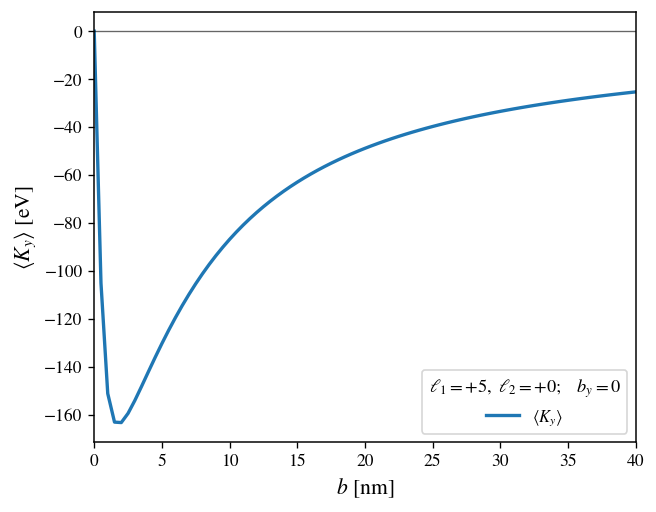

In [22]:
mean_ky_vs_b_ev = np.empty_like(b_values_nm)
b_iterator = tqdm(
    b_values_nm,
    desc="Impact scan",
    unit="point",
    disable=not SHOW_PROGRESS,
)

for index, b_nm in enumerate(b_iterator):
    impact_at_b = np.array((b_nm / mv.HBARC_MEV_NM, 0.0))
    mean_ky_vs_b_ev[index] = (
        mv.mean_total_momentum(
            packet1,
            packet2,
            probability_grid,
            impact=impact_at_b,
        )[1]
        * MEV_TO_EV
    )

fig, ax = plt.subplots(figsize=(5.6, 4.4))
ax.plot(
    b_values_nm,
    mean_ky_vs_b_ev,
    linewidth=2.0,
    label=r"$\langle K_y \rangle$",
)
ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.6)
ax.set(
    xlabel=r"$b$ [nm]",
    ylabel=r"$\langle K_y \rangle$ [eV]",
    xlim=b_range_nm,
)
ax.legend(
    title=rf"$\ell_1={packet1.ell:+d},\ \ell_2={packet2.ell:+d};\quad b_y=0$"
)
save_figure(fig, "mean_ky_vs_impact.png")

## Mean transverse momentum for different OAM combinations

OAM impact panel: 100%|██████████| 648/648 [00:24<00:00, 26.87point/s] 


Saved figure: figures\mean_ky_oam_panel.png


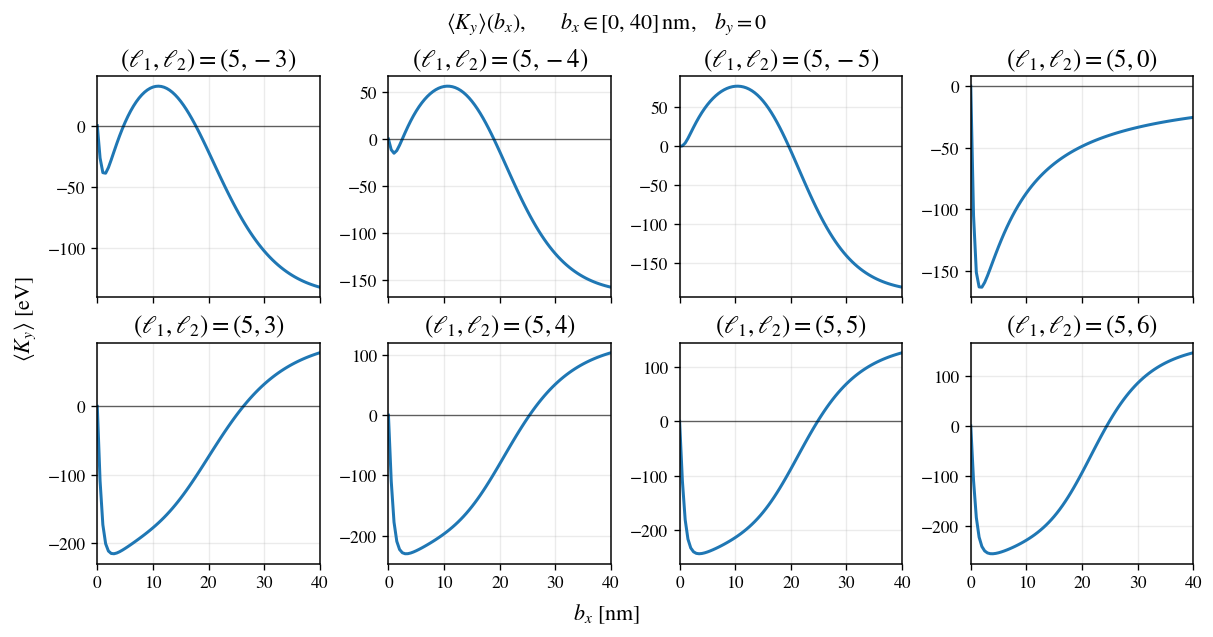

In [24]:
mean_ky_oam_panel_ev = []
oam_impact_progress = tqdm(
    total=len(ell_pairs) * len(b_values_nm),
    desc="OAM impact panel",
    unit="point",
    disable=not SHOW_PROGRESS,
)

for panel_ell1, panel_ell2 in ell_pairs:
    panel_packet1 = rebuild_packet(packet1, ell=panel_ell1)
    panel_packet2 = rebuild_packet(packet2, ell=panel_ell2)

    if panel_packet1 is packet1 and panel_packet2 is packet2:
        panel_mean_ky_ev = mean_ky_vs_b_ev.copy()
        oam_impact_progress.update(len(b_values_nm))
    else:
        panel_mean_ky_ev = np.empty_like(b_values_nm)
        for index, b_nm in enumerate(b_values_nm):
            impact_at_b = np.array((b_nm / mv.HBARC_MEV_NM, 0.0))
            panel_mean_ky_ev[index] = (
                mv.mean_total_momentum(
                    panel_packet1,
                    panel_packet2,
                    probability_grid,
                    impact=impact_at_b,
                )[1]
                * MEV_TO_EV
            )
            oam_impact_progress.update()

    mean_ky_oam_panel_ev.append(panel_mean_ky_ev)

oam_impact_progress.close()
mean_ky_oam_panel_ev = np.asarray(mean_ky_oam_panel_ev)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(10.0, 5.2),
    sharex=True,
    constrained_layout=True,
)
visible_axes = axes.ravel()[:len(ell_pairs)]

for ax, (panel_ell1, panel_ell2), panel_mean_ky_ev in zip(
    visible_axes, ell_pairs, mean_ky_oam_panel_ev
):
    ax.plot(b_values_nm, panel_mean_ky_ev, linewidth=1.8)
    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.6)
    ax.set_title(rf"$(\ell_1,\ell_2)=({panel_ell1:d},{panel_ell2:d})$")
    ax.set_xlim(b_range_nm)
    ax.grid(alpha=0.25)

for unused_ax in axes.ravel()[len(ell_pairs):]:
    unused_ax.set_visible(False)

fig.supxlabel(r"$b_x$ [nm]")
fig.supylabel(r"$\langle K_y \rangle$ [eV]")
fig.suptitle(
    rf"$\langle K_y \rangle(b_x),\qquad "
    rf"b_x\in[{b_range_nm[0]:g},\,{b_range_nm[1]:g}]\,\mathrm{{nm}},"
    rf"\quad b_y=0$"
)
save_figure(fig, "mean_ky_oam_panel.png", tight_layout=False)